## 04 — DSP-Based Locomotion Classifier

Implements a generative classifier using KDEs fitted in notebook 03.

- Compute pairwise Jensen-Shannon divergence between activity KDEs per channel
- Select informative channels based on JS divergence threshold
- Score incoming windows from held-out subject (subject101) using per-channel 
  log-likelihood under fitted KDEs
- Aggregate log-likelihoods across retained channels (Naive Bayes assumption)
- Predict activity class as highest scoring KDE
- Evaluate: accuracy, confusion matrix, F1

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False
import matplotlib.pyplot as plt
%matplotlib widget 
from sklearn.neighbors import KernelDensity
from pathlib import Path
from scipy.signal import butter, sosfiltfilt
from scipy.spatial.distance import jensenshannon
import sys
sys.path.append('..')
import src.utils as utils

In [2]:
# Constants

DATA_DIR = "/Volumes/LPM02 storage/Datasets/Bio/PAMAP2/PAMAP2_Dataset/Protocol"

COL_MAP = {
    'timestamp':    0,
    'activity_id':  1,
    'hand_acc16_y': 4,
    'hand_acc16_z': 5,
    'hand_gyro_x':  8,
    'hand_gyro_y':  9,
}

EXCLUDE_SUBJECTS = ['subject103', 'subject104', 'subject109']  # from EDA, these subjects' data was found to be missing or low quality
HOLD_OUT = 'subject101'                                        # Could be any of the retained subjects

ACCEL_COLS = ['hand_acc16_y', 'hand_acc16_z']
GYRO_COLS = ['hand_gyro_x', 'hand_gyro_y']
SIGNAL_COLS = ACCEL_COLS + GYRO_COLS

ACTIVITIES = {4: 'Walking', 5: 'Running', 12: 'Stair Ascent', 13: 'Stair Descent'}

FC = 15            # center freq for LPF
FS = 100           # samplerate
BANDWIDTH = 0.02   # KDE Gaussian bandwidth (instead of 'scott')
WINDOW_SIZE = 256  # for gathering signal "chunks"

In [3]:
# Load data, keeping only subjects and activities of interest

df_all = utils.load_data(DATA_DIR, COL_MAP)
df_all = utils.exclude_subjects(df_all, EXCLUDE_SUBJECTS)
df_all = utils.filter_activities(df_all, ACTIVITIES)

print(f"Raw: {df_all.shape}")
print(f"Loaded: {df_all.shape[0]} rows, {df_all['subject'].nunique()} subjects")

Raw: (441508, 7)
Loaded: 441508 rows, 6 subjects


In [4]:
# Preprocess data

df_preproc = utils.preprocess(df_all, ACCEL_COLS, GYRO_COLS, fc=FC, fs=FS)

print(f"Preprocessed: {df_preproc.shape}")

Preprocessed: (441508, 7)


In [5]:
# Split data for train/test

df_train, df_test = utils.train_test_split(df_preproc, HOLD_OUT)

print(f"Train: {df_train['subject'].unique()}")
print(f"Test: {df_test['subject'].unique()}")

Train: ['subject102' 'subject105' 'subject106' 'subject107' 'subject108']
Test: ['subject101']


In [6]:
# KDE fitting for each channel of each activity

kde_models = {}

for activity_id, activity_name in ACTIVITIES.items():
    kde_models[activity_id] = {}
    train_activity = df_train[df_train['activity_id'] == activity_id]
    
    for col in SIGNAL_COLS:
        values = train_activity[col].dropna().values.reshape(-1, 1)
        kde = KernelDensity(kernel='gaussian', bandwidth=BANDWIDTH)
        kde.fit(values)
        kde_models[activity_id][col] = kde
    
    print(f"Fitted KDE for {activity_name}")

Fitted KDE for Walking
Fitted KDE for Running
Fitted KDE for Stair Ascent
Fitted KDE for Stair Descent


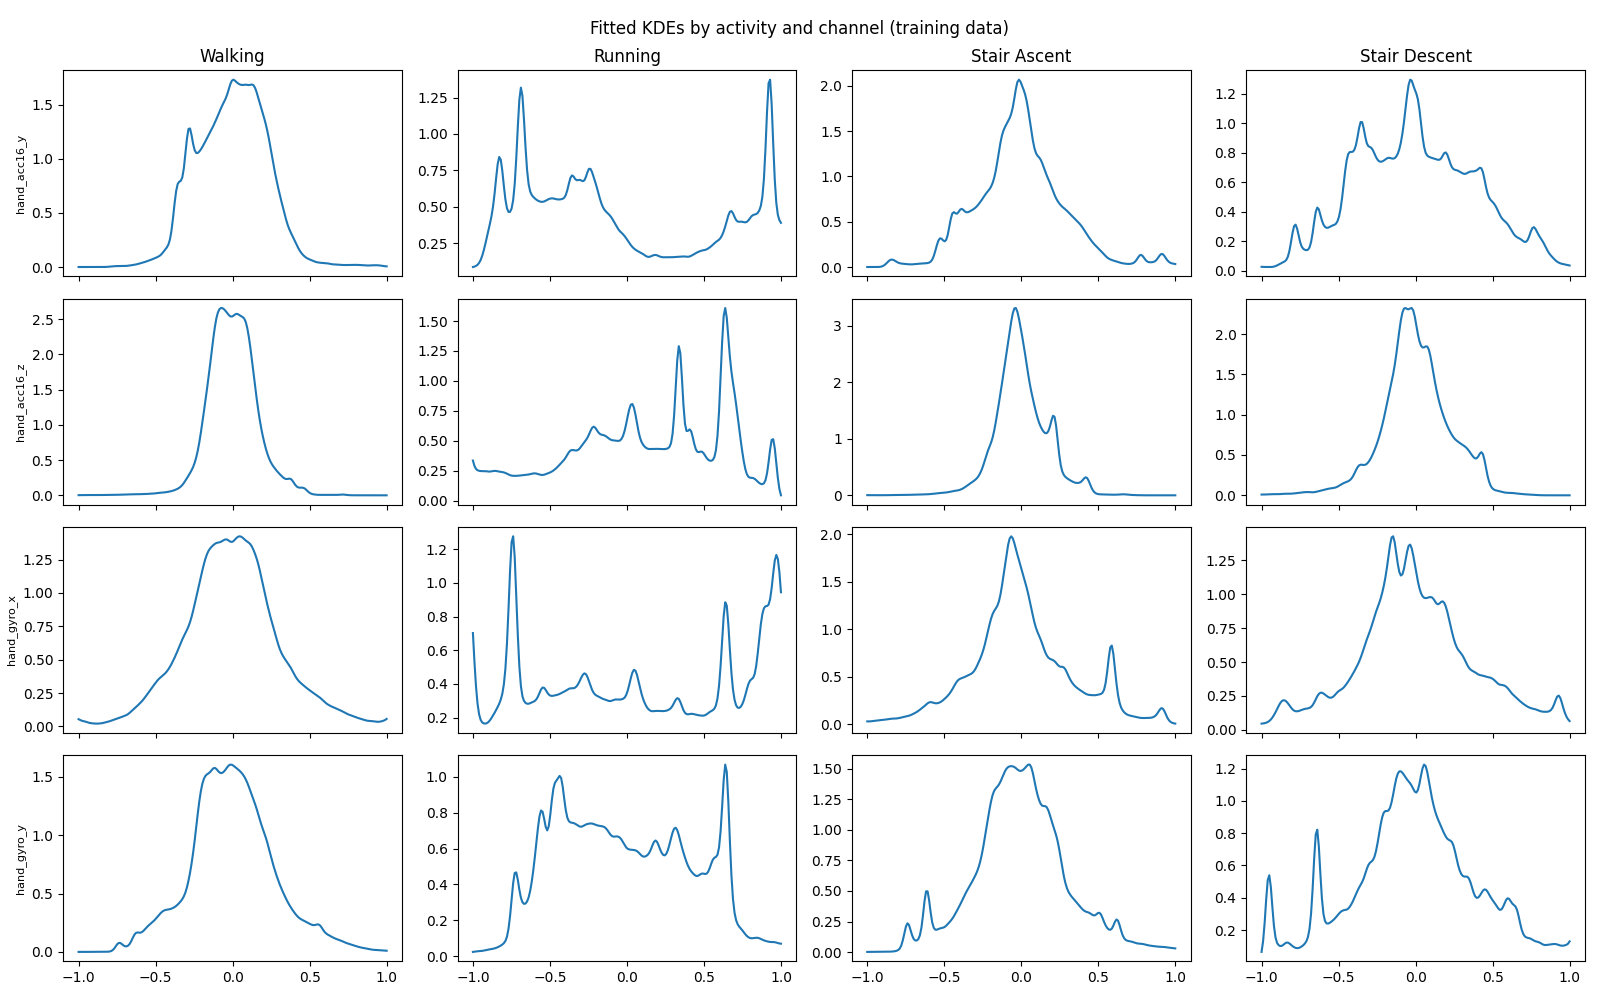

In [7]:
# Inspec KDEs

plt.close('all')

x_plot = np.linspace(-1, 1, 200).reshape(-1, 1)

fig, axes = plt.subplots(len(SIGNAL_COLS), len(ACTIVITIES), figsize=(16, 10), sharex=True)

for col_idx, (activity_id, activity_name) in enumerate(ACTIVITIES.items()):
    for row_idx, col in enumerate(SIGNAL_COLS):
        ax = axes[row_idx, col_idx]
        
        log_density = kde_models[activity_id][col].score_samples(x_plot)
        ax.plot(x_plot, np.exp(log_density), linewidth=1.5)
        
        if row_idx == 0:
            ax.set_title(activity_name)
        if col_idx == 0:
            ax.set_ylabel(col, fontsize=8)

fig.suptitle('Fitted KDEs by activity and channel (training data)')
plt.tight_layout()
plt.show()

In [8]:
# Jensen Shannon Dist for channel selection

from itertools import combinations

js_scores = {}

for col in SIGNAL_COLS:
    pairwise_js = []
    
    for act_a, act_b in combinations(ACTIVITIES.keys(), 2):
        p = np.exp(kde_models[act_a][col].score_samples(x_plot))
        q = np.exp(kde_models[act_b][col].score_samples(x_plot))
        js = jensenshannon(p, q)
        pairwise_js.append(js)
    
    js_scores[col] = np.mean(pairwise_js)
    print(f"{col}: mean JS divergence = {js_scores[col]:.4f}")

hand_acc16_y: mean JS divergence = 0.3400
hand_acc16_z: mean JS divergence = 0.3004
hand_gyro_x: mean JS divergence = 0.2603
hand_gyro_y: mean JS divergence = 0.2024


**Jensen-Shannon Distance computed for all four channels**  
All channels show similar (presumably meaningful) inter-class separability (range: 0.207 - 0.328) — no channels 
excluded. hand_gyro_y is the weakest discriminator; hand_gyro_x the strongest.

In [9]:
# Inference

bin_edges = np.linspace(-1, 1, 201)
bin_centers = ((bin_edges[:-1] + bin_edges[1:]) / 2).reshape(-1, 1)

log_densities = {
    activity_id: {
        col: kde_models[activity_id][col].score_samples(bin_centers)
        for col in SIGNAL_COLS
    }
    for activity_id in ACTIVITIES.keys()
}

results = []

for activity_id, activity_name in ACTIVITIES.items():
    test_activity = df_test[df_test['activity_id'] == activity_id].reset_index(drop=True)
    n_windows = len(test_activity) // WINDOW_SIZE
    print(f"Scoring {activity_name}: {n_windows} windows...")
    
    for i in range(n_windows):
        window = test_activity.iloc[i * WINDOW_SIZE:(i + 1) * WINDOW_SIZE]
        
        log_likelihoods = {}
        for candidate_id in ACTIVITIES.keys():
            ll = 0
            for col in SIGNAL_COLS:
                hist, _ = np.histogram(window[col].dropna().values,
                                       bins=bin_edges, density=False)
                n = hist.sum()
                if n > 0:
                    ll += np.dot(hist / n, log_densities[candidate_id][col])
            log_likelihoods[candidate_id] = ll
        
        predicted = max(log_likelihoods, key=log_likelihoods.get)
        results.append({'true': activity_id, 'predicted': predicted})

df_results = pd.DataFrame(results)
print(f"\nTotal windows evaluated: {len(df_results)}")
print(df_results.head())

Scoring Walking: 86 windows...
Scoring Running: 83 windows...
Scoring Stair Ascent: 62 windows...
Scoring Stair Descent: 58 windows...

Total windows evaluated: 289
   true  predicted
0     4         13
1     4         13
2     4         13
3     4         13
4     4          4


In [10]:
# Result evaluation

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix

y_true = df_results['true'].map(ACTIVITIES)
y_pred = df_results['predicted'].map(ACTIVITIES)

print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_true, y_pred))


cm = confusion_matrix(y_true, y_pred, labels=list(ACTIVITIES.values()))
cm_df = pd.DataFrame(cm, index=list(ACTIVITIES.values()), columns=list(ACTIVITIES.values()))
cm_df.index.name = 'True'
cm_df.columns.name = 'Predicted'
print(cm_df)

Accuracy: 0.6125

Classification Report:
               precision    recall  f1-score   support

      Running       0.93      0.93      0.93        83
 Stair Ascent       0.47      0.56      0.51        62
Stair Descent       0.30      0.21      0.24        58
      Walking       0.58      0.62      0.60        86

     accuracy                           0.61       289
    macro avg       0.57      0.58      0.57       289
 weighted avg       0.60      0.61      0.60       289

Predicted      Walking  Running  Stair Ascent  Stair Descent
True                                                        
Walking             53        2            19             12
Running              0       77             0              6
Stair Ascent        15        2            35             10
Stair Descent       23        2            21             12


## Results and Conclusions

### DSP Classifier Performance (subject101 held out)

| Metric | Value |
|--------|-------|
| Overall accuracy | 61.3% |
| Running F1 | 0.93 |
| Walking F1 | 0.60 |
| Stair Ascent F1 | 0.51 |
| Stair Descent F1 | 0.24 |

### Key Findings

- Running classified with high confidence (F1=0.93)
   - Amplitude distribution is distinctly different from other activities
- Stair descent remains the weakest class (F1=0.24)
   - Confused primarily with walking and stair ascent
   - Likely shares similar wrist amplitude distributions with both
- Walking and stair ascent show meaningful improvement over initial implementation
   - Fixes to filter boundary handling and histogram weighting contributed

### Motivation for 1D CNN

- Histogram-based approach discards temporal structure by design
- Stair ascent/descent confusion suggests discriminative features are temporal
- 1D CNN on raw windowed signals preserves time ordering
- Next notebook implements 1D CNN on same train/test split for direct comparison